# E45 - The Recession Round: war-gaming the pair hazard (H420-H425)

**Author**: kj · **Round**: E45 · **Campaign**: demographic-collapse (H420-H425, campaign → 425)

E44 identified the campaign's sharpest live hazard: a security deterioration colliding with the
parental-hardship broadcast on the W field tips the norm super-additively, and the data-anchored
turbulence amplifies it strongly. Recessions are not hypothetical forcings - after a
falling-GDP year the period TFR declined in ~4/5 of country-years (odds ratio 4.2, Sobotka
2011). This round maps the danger zone and prices the defenses.

**Approach**:
1. The tipping frontier - recession (depth x duration) thresholds per low-well region under
   anchored noise (H420), and the turbulence tax on that envelope (H424)
2. The defenses - floor protection during the shock (H421), protect-during vs repair-after at
   equal budget (H422), floor protection vs broadcast dampening at equal cost (H423)
3. The physics check - does the tilted-barrier arithmetic price the defense (H425)?

**Wires** (the E44 calibration, unchanged): broadcast bundle pen_scale=1, gWrv=0.3, gWN=0.01;
recession = a sustained fS shock; per-region eps from `reports/e43_epsilon_anchor.md`.
**Output**: verdicts → `reports/nb42_e45_verdicts.json`, figures → `reports/figures/nb42_*.png`.

## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import os
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "GPU-58ae1f45-295c-681b-60ad-843265f52997")
import sys
sys.path.insert(0, "../src")

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import brentq
from rich import print as rprint

from sci_demographic_collapse import emergent as em

2026-07-11 19:03:02.945 | INFO     | sci_demographic_collapse.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/learning/projects/sci-demographic-collapse


## Reproducibility

In [2]:
SEED = 42
np.random.seed(SEED)
NOISE_SEED = 1234

## Configuration

Constants from the live core; the E43 noise anchor; the E44 broadcast bundle. The recession
grid spans observed severities: depth as a security shock (the 2008/COVID-class shocks in the
E10 crisis battery ran fS ~ -0.1..-0.3) and duration 4-20 years.

In [3]:
REGIONS = list(em.REAL)
YEARS = 102
_base = em.EmergentModel("../data/raw/unwpp")
PN = {k: _base.P[k] for k in ("aN", "Nlo", "thN", "Nhi")}
A_, B_, C_ = PN["Nlo"], PN["thN"], PN["Nhi"]

EPS_REG = {"USA": 2.2e-5, "Japan": 3.1e-5, "Italy": 4.2e-5, "Israel": 4.3e-5,
           "France": 5.4e-5, "Germany": 6.4e-5, "Korea": 8.5e-5, "Poland": 1.1e-4}

# --- the E44 broadcast bundle (unchanged) + the E42 layer parameters ---------------------------
BCAST = dict(pen_scale=1.0, gWrv=0.3, gWN=0.01)
E_CEIL = 0.85
ATT = pd.read_csv("../data/raw/oecd/tertiary_attainment_women_25_34.csv")
ISO = {"USA": "USA", "France": "FRA", "Germany": "DEU", "Italy": "ITA",
       "Japan": "JPN", "Korea": "KOR", "Poland": "POL", "Israel": "ISR"}
_ISO_COL = "iso3" if "iso3" in ATT.columns else ATT.columns[0]
_VAL_COL = [c for c in ATT.columns if ATT[c].dtype.kind == "f"][-1]
_YR_COL = [c for c in ATT.columns if "year" in c.lower()][0]
E0_ATT, E_RATE = {}, {}
for nm, iso in ISO.items():
    g = ATT[ATT[_ISO_COL] == iso].sort_values(_YR_COL)
    yrs, vals = g[_YR_COL].to_numpy(float), g[_VAL_COL].to_numpy(float) / 100.0
    E0_ATT[nm] = float(vals[-1])
    gap = np.clip(E_CEIL - vals, 1e-3, None)
    r = -np.polyfit(yrs, np.log(gap), 1)[0] if len(vals) > 3 else 0.02
    E_RATE[nm] = float(np.clip(r, 0.0, 0.05))
P_EW = dict(kE=0.04, race=0.5, sigE=0.08, YRS_PER_SHARE=4.5,
            kW=0.5, aWS=1.2, lamLA=2.25, W_floor=-0.15)
PEN = {"USA": -0.127, "Korea": -0.10, "Japan": -0.09, "Italy": -0.06,
       "Poland": -0.05, "Germany": -0.04, "Israel": -0.02, "France": -0.01}
EQ = {"Korea": 0.25, "Japan": 0.30, "Italy": 0.35, "Poland": 0.40,
      "Germany": 0.55, "Israel": 0.55, "USA": 0.65, "France": 0.70}

DEPTHS = (0.10, 0.15, 0.20, 0.25, 0.30)     # fS shock magnitudes (E10 crisis-class)
DURS = (4, 8, 12, 20)                        # shock durations, years (start year 5)
LOW_WELL = ("USA", "France", "Germany")      # the tipping-prone regions

rprint("[bold]E45 configuration[/bold]")
rprint(f"  [bold]Broadcast bundle[/bold]  {BCAST} (the E44 pair calibration)")
rprint(f"  [bold]Recession grid[/bold]  depths {DEPTHS} x durations {DURS} (start year 5)")
rprint(f"  [bold]eps[/bold]  " + "  ".join(f"{n}:{v:.1e}" for n, v in EPS_REG.items() if n in LOW_WELL + ('Poland',)))

E45 configuration

Broadcast bundle  {'pen_scale': 1.0, 'gWrv': 0.3, 'gWN': 0.01} (the E44 pair calibration)

Recession grid  depths (0.1, 0.15, 0.2, 0.25, 0.3) x durations (4, 8, 12, 20) (start year 5)

eps  USA:2.2e-05  France:5.4e-05  Germany:6.4e-05  Poland:1.1e-04

## The models (ported, equivalence re-asserted) and the hard gate

In [4]:
class NoiseModel(em.EmergentModel):
    """Per-strand dynamic noise on N via the effective force. eps=0 -> bit-identical."""

    def __init__(self, *a, eps=0.0, noise_seed=NOISE_SEED, **kw):
        super().__init__(*a, **kw)
        self.eps = float(eps)
        self.noise_seed = noise_seed

    def run_ens(self, region, *a, **kw):
        self._nrng = np.random.default_rng(self.noise_seed)
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        if self.eps > 0.0:
            f = list(force) + [0.0] * (7 - len(force))
            f[5] = f[5] + np.sqrt(2.0 * self.eps / dt) * self._nrng.standard_normal(st.shape[0])
            force = f
        return super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)


class E42L(NoiseModel):
    """The E42 E/W layer ported (NB38 lineage). Loadings default 0 -> inert."""

    DEFAULTS = dict(gEtau=0.0, gEdot=0.0, gES=0.0, gErv=0.0,
                    gWrv=0.0, gWdot=0.0, gWN=0.0, fE=0.0, fW=0.0, fWh=0.0, pen_scale=0.0)

    def __init__(self, *a, ew=None, **kw):
        super().__init__(*a, **kw)
        self.EW = dict(P_EW)
        self.EW.update(self.DEFAULTS)
        if ew:
            self.EW.update(ew)

    def run_ens(self, region, *a, **kw):
        K = kw.get("K", 64)
        e = self.EW
        z = (np.arange(K) + 0.5) / K - 0.5
        rng = np.random.default_rng(kw.get("seed", 0) + 7)
        self._E = np.clip(E0_ATT[region] + e["sigE"] * 2.0 * z[rng.permutation(K)], 0.02, 0.98)
        self._W = np.zeros(K)
        self._hab = np.zeros(K)
        self._Eprev, self._Wprev = self._E.copy(), self._W.copy()
        self._dEdt, self._dWdt = np.zeros(K), np.zeros(K)
        self._sub, self._E0r, self._rEr = 0, E0_ATT[region], E_RATE[region]
        self._penr, self._eqr = PEN[region], EQ[region]
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        e = self.EW
        loaded = any(e[k] != 0.0 for k in ("gEtau", "gEdot", "gES", "gErv", "gWrv", "gWdot", "gWN"))
        if loaded:
            f = list(force) + [0.0] * (7 - len(force))
            dE, dEr = self._E - self._E0r, self._dEdt
            f[3] = f[3] + e["gEtau"] * e["YRS_PER_SHARE"] * dE + e["gEdot"] * np.clip(dEr, 0, None) * 100
            f[0] = f[0] + e["gES"] * dE
            f[4] = f[4] + e["gErv"] * dE * (1.0 - self._eqr / 0.55)
            gate = np.clip(e["W_floor"] - self._W, 0, None)
            asym = e["lamLA"] * np.clip(-self._dWdt, 0, None) - np.clip(self._dWdt, 0, None)
            f[4] = f[4] + e["gWrv"] * gate + e["gWdot"] * asym
            f[5] = f[5] - e["gWN"] * float(np.mean(self._W))
            force = f
        out, dtau = super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)
        S, rv = out[:, 4], out[:, 1]
        Esec = E_CEIL - (E_CEIL - self._E0r) * np.exp(-self._rEr * 100 * tn)
        Etgt = Esec + e["race"] * np.clip(self._E.mean() - self._E, 0, None) + e["fE"]
        self._E = np.clip(self._E + dt * e["kE"] * (Etgt - self._E), 0.02, 0.98)
        Wtgt = e["aWS"] * (S - em.S0[nm]) + e["fW"] + e["pen_scale"] * self._penr * (1 - rv)
        self._hab = self._hab + dt * e["kW"] * (e["fWh"] - self._hab)
        self._W = self._W + dt * e["kW"] * (Wtgt - self._W) + dt * (e["fWh"] - self._hab)
        self._sub += 1
        if self._sub % 4 == 0:
            self._dEdt = self._E - self._Eprev
            self._dWdt = self._W - self._Wprev
            self._Eprev, self._Wprev = self._E.copy(), self._W.copy()
        return out, dtau


VERDICTS = {}


def record(h, title, verdict, metric, note):
    VERDICTS[h] = dict(title=title, verdict=verdict, metric=metric, note=note)
    color = {"SUPPORTED": "green", "PARTIAL": "yellow", "REFUTED": "red"}[verdict]
    rprint(f"[bold {color}]{h} {verdict}[/bold {color}] - {title}")
    rprint(f"   metric: {metric}")
    rprint(f"   {note}")


base = em.EmergentModel("../data/raw/unwpp")
ew0 = E42L("../data/raw/unwpp")
BASE = {nm: base.run_cal(nm) for nm in REGIONS}
worst, worst_a = 0.0, 0.0
for nm in REGIONS:
    d = float(np.max(np.abs(BASE[nm]["TFR"] - ew0.run_cal(nm)["TFR"])))
    worst = max(worst, d)
    worst_a = max(worst_a, abs(BASE[nm]["TFR"][0] - em.REAL[nm][0]))
assert worst == 0.0, f"baseline preservation FAILED: {worst}"
assert worst_a < 5e-4, f"2023 anchor regression: {worst_a:.2e}"
rprint(f"[bold green]PASS[/bold green] - eps=0 loadings-off bit-identical 8/8 (anchors {worst_a:.1e})")


def scenario(nm, depth, dur, eps, defend=None, defend_frac=0.0, defend_when="during",
             pen_cut=0.0, start=5, K=64):
    """One recession run: fS shock -depth for [start, start+dur), the E44 broadcast bundle on,
    optional defense. Returns (TFR series, end high-well occupancy, end mean TFR delta)."""
    ew = dict(BCAST)
    if pen_cut > 0.0:
        ew["pen_scale"] = 1.0 - pen_cut
    m = E42L("../data/raw/unwpp", ew=ew, eps=eps)

    def force(yr):
        f = [0.0] * 7
        if start <= yr < start + dur:
            f[0] = -depth
            if defend == "floor" and defend_when == "during":
                f[0] += defend_frac * depth
        if defend == "floor" and defend_when == "after":
            # equal budget spent in the dur years AFTER the shock ends
            if start + dur <= yr < start + 2 * dur:
                f[0] += defend_frac * depth
        return f

    r = m.run_cal(nm, force=force, K=K, return_dist=True)
    occ = float((r["dist_end"]["N"] > B_).mean())
    return r["TFR"], occ, float(r["TFR"][-1])


def occ_ref(nm, eps):
    """The no-recession reference (bundle on, no shock): occupancy AND endpoint TFR, so every
    delta in this round is measured against the SAME reference (round-1 review D4)."""
    m = E42L("../data/raw/unwpp", ew=dict(BCAST), eps=eps)
    r = m.run_cal(nm, return_dist=True)
    return float((r["dist_end"]["N"] > B_).mean()), float(r["TFR"][-1])

PASS - eps=0 loadings-off bit-identical 8/8 (anchors 6.5e-05)

## H420 - the tipping frontier

**Hypothesis**: the pair hazard has a (depth x duration) THRESHOLD structure per region - below
the frontier recessions leave the norm basin intact, above it strands tip permanently - and the
frontier is measurably lower (more dangerous) with the broadcast bundle than without it.
**Bars**: (i) for each of USA/France/Germany at anchored eps, the tipped-strand excess
(occupancy minus the no-recession reference) crosses 3/64 somewhere in the grid AND is <= 1/64
somewhere else (a genuine frontier inside the observed severity range); (ii) with the broadcast
bundle OFF (pure fS shock, no W wires) the same grid produces < 3/64 excess everywhere - the
hazard lives in the pair, not in the recession alone.

In [5]:
FRONT = {}
for nm in LOW_WELL:
    eps = EPS_REG[nm]
    ref, ref_tfr = occ_ref(nm, eps)
    grid = {}
    for d in DEPTHS:
        for T in DURS:
            _, occ, tfr_end = scenario(nm, d, T, eps)
            grid[(d, T)] = dict(exc=float(occ - ref), dTFR_vs_ref=float(tfr_end - ref_tfr))
    FRONT[nm] = dict(ref=ref, ref_tfr=ref_tfr, grid=grid)
    worst_exc = max(v["exc"] for v in grid.values())
    best_exc = min(v["exc"] for v in grid.values())
    rprint(f"  {nm:8s} ref occ {ref:.3f}; tipped-excess range [{best_exc:+.3f}, {worst_exc:+.3f}]")

# control: the recession WITHOUT the broadcast bundle - the FULL grid (round-1 review D3)
CTRL = {}
for nm in LOW_WELL:
    nz = NoiseModel("../data/raw/unwpp", eps=EPS_REG[nm])
    r0 = nz.run_cal(nm, return_dist=True)
    ref0 = float((r0["dist_end"]["N"] > B_).mean())
    worst0 = 0.0
    for d in DEPTHS:
        for T in DURS:
            f = lambda yr, d=d, T=T: [-d if 5 <= yr < 5 + T else 0.0, 0, 0, 0, 0, 0, 0]
            rr = nz.run_cal(nm, force=f, return_dist=True)
            worst0 = max(worst0, float((rr["dist_end"]["N"] > B_).mean()) - ref0)
    CTRL[nm] = worst0
    rprint(f"  {nm:8s} bundle-OFF worst excess {worst0:+.3f} (full {len(DEPTHS)}x{len(DURS)} grid)")

ok_i = all(max(v["exc"] for v in FRONT[nm]["grid"].values()) >= 3 / 64
           and min(v["exc"] for v in FRONT[nm]["grid"].values()) <= 1 / 64 for nm in LOW_WELL)
ok_ii = all(CTRL[nm] < 3 / 64 for nm in LOW_WELL)
verdict = "SUPPORTED" if (ok_i and ok_ii) else ("PARTIAL" if ok_i else "REFUTED")
record("H420", "the recession tipping frontier exists, and it lives in the pair", verdict,
       f"tipped-excess ranges: { {nm: [round(min(v['exc'] for v in FRONT[nm]['grid'].values()), 3), round(max(v['exc'] for v in FRONT[nm]['grid'].values()), 3)] for nm in LOW_WELL} }; "
       f"bundle-OFF worst: { {nm: round(v, 3) for nm, v in CTRL.items()} }",
       "Recessions carry a norm-basin threshold: below the frontier the basin holds, above it "
       "strands tip permanently - and the danger is the PAIR (deterioration feeding the "
       "hardship broadcast), not the recession alone: with the W wires off the same shocks tip "
       "almost nothing. The frontier is the policy object: it says how much recession a country "
       "can absorb before fertility damage becomes cultural, not cyclical." if (ok_i and ok_ii) else
       ("The frontier exists but the bundle-off control also tips - the hazard is not cleanly "
        "the pair." if ok_i else "No frontier inside the observed severity range."))

USA      ref occ 0.328; tipped-excess range [+0.016, +0.422]

France   ref occ 0.172; tipped-excess range [+0.000, +0.312]

Germany  ref occ 0.391; tipped-excess range [+0.000, +0.219]

USA      bundle-OFF worst excess +0.000 (full 5x4 grid)

France   bundle-OFF worst excess +0.000 (full 5x4 grid)

Germany  bundle-OFF worst excess +0.000 (full 5x4 grid)

H420 SUPPORTED - the recession tipping frontier exists, and it lives in the pair

metric: tipped-excess ranges: {'USA': [0.016, 0.422], 'France': [0.0, 0.312], 'Germany': [0.0, 0.219]}; 
bundle-OFF worst: {'USA': 0.0, 'France': 0.0, 'Germany': 0.0}

Recessions carry a norm-basin threshold: below the frontier the basin holds, above it strands tip permanently - 
and the danger is the PAIR (deterioration feeding the hardship broadcast), not the recession alone: with the W 
wires off the same shocks tip almost nothing. The frontier is the policy object: it says how much recession a 
country can absorb before fertility damage becomes cultural, not cyclical.

## H421 - floor protection prevents the tips

**Hypothesis**: security support DURING the shock, sized at half the shock, prevents most
pair-induced tipping - automatic stabilizers are fertility policy.
**Bars**: SUPPORTED if at the worst grid corner (depth 0.30, 20y) with defend_frac=0.5 the
tipped excess falls by >= 80% vs undefended in >= 2 of 3 regions; REFUTED if the defense
backfires (prevented < 0) in >= 2 regions; PARTIAL otherwise.

In [6]:
H421 = {}
for nm in LOW_WELL:
    eps = EPS_REG[nm]
    ref = FRONT[nm]["ref"]
    exc0 = FRONT[nm]["grid"][(0.30, 20)]["exc"]
    _, occ_d, _ = scenario(nm, 0.30, 20, eps, defend="floor", defend_frac=0.5)
    exc_d = float(occ_d - ref)
    H421[nm] = dict(undefended=exc0, defended=exc_d,
                    prevented=float(1 - exc_d / exc0) if exc0 > 1e-9 else np.nan)
    rprint(f"  {nm:8s} tipped excess {exc0:+.3f} -> {exc_d:+.3f} with 50% floor support "
           f"({H421[nm]['prevented']*100 if exc0 > 1e-9 else float('nan'):.0f}% prevented)")
ok = sum(v["prevented"] >= 0.8 for v in H421.values() if np.isfinite(v["prevented"])) >= 2
bad = sum(v["prevented"] < 0 for v in H421.values() if np.isfinite(v["prevented"])) >= 2
record("H421", "floor protection during the shock prevents the tips",
       "SUPPORTED" if ok else ("REFUTED" if bad else "PARTIAL"),
       f"prevented fractions { {nm: round(v['prevented'], 2) for nm, v in H421.items()} } at the worst corner (0.30 x 20y, 50% support)",
       "Automatic stabilizers ARE fertility policy: half-sized security support during the "
       "recession removes most of the permanent norm damage - the cheapest time to defend the "
       "basin is while the shock runs, exactly when budgets are tightest." if ok else
       "Half-sized support does not clear the 80% bar broadly - the defense needs fuller sizing.")

USA      tipped excess +0.422 -> +0.219 with 50% floor support (48% prevented)

France   tipped excess +0.312 -> +0.125 with 50% floor support (60% prevented)

Germany  tipped excess +0.219 -> +0.125 with 50% floor support (43% prevented)

H421 PARTIAL - floor protection during the shock prevents the tips

metric: prevented fractions {'USA': 0.48, 'France': 0.6, 'Germany': 0.43} at the worst corner (0.30 x 20y, 50% 
support)

Half-sized support does not clear the 80% bar broadly - the defense needs fuller sizing.

## H422 - protect-during beats repair-after at equal budget

**Hypothesis**: hysteresis makes the timing decisive - the same budget spent AFTER the shock
recovers far less than spent DURING prevents.
**Bars**: SUPPORTED if at the worst corner the after-arm's prevented fraction is < 50% of the
during-arm's in >= 2 of 3 regions; REFUTED if the timing premium is absent or reversed
(after >= 0.9 x during) in >= 2 of 3; PARTIAL otherwise.

In [7]:
H422 = {}
for nm in LOW_WELL:
    eps = EPS_REG[nm]
    ref = FRONT[nm]["ref"]
    exc0 = FRONT[nm]["grid"][(0.30, 20)]["exc"]
    _, occ_a, _ = scenario(nm, 0.30, 20, eps, defend="floor", defend_frac=0.5, defend_when="after")
    exc_a = float(occ_a - ref)
    prev_a = float(1 - exc_a / exc0) if exc0 > 1e-9 else np.nan
    H422[nm] = dict(after=prev_a, during=H421[nm]["prevented"])
    rprint(f"  {nm:8s} prevented: during {H421[nm]['prevented']*100:.0f}% vs after {prev_a*100:.0f}%")
ok = sum((v["after"] < 0.5 * v["during"]) for v in H422.values()
         if np.isfinite(v["after"]) and np.isfinite(v["during"])) >= 2
flat = sum((v["after"] >= 0.9 * v["during"]) for v in H422.values()
           if np.isfinite(v["after"]) and np.isfinite(v["during"])) >= 2
verdict = "SUPPORTED" if ok else ("REFUTED" if flat else "PARTIAL")
record("H422", "protect-during beats repair-after at equal budget", verdict,
       f"{ {nm: dict(during=round(v['during'], 2), after=round(v['after'], 2)) for nm, v in H422.items()} }",
       "Hysteresis prices the timing: once strands cross the norm barrier the same money buys "
       "back less than half of what it would have protected - post-crisis family packages "
       "arrive after the basin damage is locked in. Defend during, not after." if ok else
       ("REFUTED: the timing premium does not exist at this severity - the after-arm recovers "
        "about as much as the during-arm prevents (and beats it in Germany). At severe corners "
        "both arms are equally half-effective; the hysteresis-prices-the-timing story dies on "
        "its own bar, and the practical rule collapses to SIZE, not timing." if flat else
        "The after-arm recovers more than half - hysteresis is weaker than the barrier picture suggests."))

USA      prevented: during 48% vs after 44%

France   prevented: during 60% vs after 55%

Germany  prevented: during 43% vs after 50%

H422 REFUTED - protect-during beats repair-after at equal budget

metric: {'USA': {'during': 0.48, 'after': 0.44}, 'France': {'during': 0.6, 'after': 0.55}, 'Germany': {'during':
0.43, 'after': 0.5}}

REFUTED: the timing premium does not exist at this severity - the after-arm recovers about as much as the 
during-arm prevents (and beats it in Germany). At severe corners both arms are equally half-effective; the 
hysteresis-prices-the-timing story dies on its own bar, and the practical rule collapses to SIZE, not timing.

## H423 - the counter-lever duel: floor support vs broadcast dampening

**Hypothesis**: at equal nominal cost, cutting the hardship broadcast (halving the parenthood
penalty - reconciliation policy) rivals floor support, because it attacks the pair's OTHER arm.
**Bar**: pen_cut=0.5 prevents >= 50% of the worst-corner tips in >= 2 of 3 regions; the round
reports which arm dominates per region (either outcome adjudicates the duel).

In [8]:
H423 = {}
for nm in LOW_WELL:
    eps = EPS_REG[nm]
    ref = FRONT[nm]["ref"]
    exc0 = FRONT[nm]["grid"][(0.30, 20)]["exc"]
    _, occ_p, _ = scenario(nm, 0.30, 20, eps, pen_cut=0.5)
    exc_p = float(occ_p - ref)
    prev_p = float(1 - exc_p / exc0) if exc0 > 1e-9 else np.nan
    H423[nm] = dict(pen=prev_p, floor=H421[nm]["prevented"])
    rprint(f"  {nm:8s} prevented: floor 50% {H421[nm]['prevented']*100:.0f}% vs penalty-cut 50% {prev_p*100:.0f}%")
ok = sum(v["pen"] >= 0.5 for v in H423.values() if np.isfinite(v["pen"])) >= 2
bad = sum(v["pen"] < 0 for v in H423.values() if np.isfinite(v["pen"])) >= 2
winner = {nm: ("floor" if v["floor"] >= v["pen"] else "penalty-cut") for nm, v in H423.items()}
record("H423", "the counter-lever duel: floor support vs broadcast dampening",
       "SUPPORTED" if ok else ("REFUTED" if bad else "PARTIAL"),
       f"prevented { {nm: dict(floor=round(v['floor'], 2), pen=round(v['pen'], 2)) for nm, v in H423.items()} }; winner per region {winner}",
       "Both arms of the pair are defensible: halving the parenthood penalty (reconciliation "
       "policy - childcare access, workplace protection) prevents a majority of the tips, "
       "attacking the broadcast where floor support attacks the deterioration. The duel's "
       "per-region winner is recorded; the deeper point is that EITHER arm, defended, breaks "
       "the super-additive collision." if ok else
       "Penalty dampening under-delivers - the deterioration arm dominates the pair.")

USA      prevented: floor 50% 48% vs penalty-cut 50% 59%

France   prevented: floor 50% 60% vs penalty-cut 50% 15%

Germany  prevented: floor 50% 43% vs penalty-cut 50% 14%

H423 PARTIAL - the counter-lever duel: floor support vs broadcast dampening

metric: prevented {'USA': {'floor': 0.48, 'pen': 0.59}, 'France': {'floor': 0.6, 'pen': 0.15}, 'Germany': 
{'floor': 0.43, 'pen': 0.14}}; winner per region {'USA': 'penalty-cut', 'France': 'floor', 'Germany': 'floor'}

Penalty dampening under-delivers - the deterioration arm dominates the pair.

## H424 - the turbulence tax

**Hypothesis**: the safe envelope shrinks with the regional wobble - the same recession tips
more at higher eps.
**Bars**: SUPPORTED if on Germany's grid corner (0.20 x 12y) the tipped excess is monotone
non-decreasing across eps in {2.2e-5, 6.4e-5, 1.1e-4} with top-vs-bottom >= 2/64; REFUTED if it
is strictly DECREASING with spread >= 2/64 (an inverted tax); PARTIAL otherwise.

In [9]:
H424 = []
for eps in (2.2e-5, 6.4e-5, 1.1e-4):
    m = E42L("../data/raw/unwpp", ew=dict(BCAST), eps=eps)
    r0 = m.run_cal("Germany", return_dist=True)
    ref = float((r0["dist_end"]["N"] > B_).mean())
    _, occ, _ = scenario("Germany", 0.20, 12, eps)
    H424.append(dict(eps=eps, exc=float(occ - ref)))
    rprint(f"  Germany @ eps {eps:.1e}: tipped excess {H424[-1]['exc']:+.3f}")
vals = [h["exc"] for h in H424]
ok = vals[0] <= vals[1] <= vals[2] and (vals[2] - vals[0]) >= 2 / 64
inv = vals[0] > vals[1] > vals[2] and (vals[0] - vals[2]) >= 2 / 64
record("H424", "the turbulence tax on recession resilience",
       "SUPPORTED" if ok else ("REFUTED" if inv else "PARTIAL"),
       f"Germany 0.20x12y excess across eps: { {f'{h['eps']:.1e}': round(h['exc'], 3) for h in H424} }",
       "The same recession does more permanent damage in a more turbulent society: wobble "
       "and shock compound, so the countries with the noisiest family norms (Poland's "
       "measured wobble is 5x the USA's) have the thinnest safe envelope - and the least "
       "room to treat a downturn as merely cyclical." if ok else
       "The tax is not monotone or too small - turbulence and shock do not compound cleanly here.")

Germany @ eps 2.2e-05: tipped excess +0.078

Germany @ eps 6.4e-05: tipped excess +0.078

Germany @ eps 1.1e-04: tipped excess +0.078

H424 PARTIAL - the turbulence tax on recession resilience

metric: Germany 0.20x12y excess across eps: {'2.2e-05': 0.078, '6.4e-05': 0.078, '1.1e-04': 0.078}

The tax is not monotone or too small - turbulence and shock do not compound cleanly here.

## H425 - the Kramers pricing check

**Hypothesis**: the defense arithmetic is barrier arithmetic - the floor support works because
it keeps the effective tilt on the norm well sub-fold; the tilted-barrier calculation predicts
which (depth, defense) pairs tip.
**Bars**: compute the effective mean fN forcing on the norm well during the shock (the
broadcast term gWN * (-mean W) measured from the runs), classify each worst-corner arm
(undefended / floor-defended) as super- or sub-fold by the tilted-barrier criterion, and
require the classification to match the observed tipping (>= 3/64 vs < 3/64) in >= 5 of the 6
(region x arm) cells - AND the observed cells must span both classes (a set where every cell
tips cannot discriminate a threshold criterion from an always-tip rule; verdict capped at
PARTIAL in that case, the H396 lesson).

In [10]:
drift = lambda N, fN=0.0: -PN["aN"] * (N - A_) * (N - B_) * (N - C_) + fN  # noqa: E731


def fold_in():
    lo_f, hi_f = 0.0, 0.02
    for _ in range(40):
        mid = 0.5 * (lo_f + hi_f)
        xs = np.linspace(0.02, 0.98, 2000)
        n = len(np.where(np.diff(np.sign(drift(xs, mid))) != 0)[0])
        if n < 3:
            hi_f = mid
        else:
            lo_f = mid
    return 0.5 * (lo_f + hi_f)


FOLD_IN = fold_in()


class WTrace(E42L):
    def run_ens(self, region, *a, **kw):
        self._wtr = []
        return super().run_ens(region, *a, **kw)

    def _estep_vec(self, nm, st, force, tn, dep_pen, A_lag=0.0, dt=0.25):
        out, dtau = super()._estep_vec(nm, st, force, tn, dep_pen, A_lag, dt)
        if self._sub % 4 == 0:
            self._wtr.append(float(np.mean(self._W)))
        return out, dtau


H425 = {}
hits = 0
for nm in LOW_WELL:
    eps = EPS_REG[nm]
    for arm, kw in (("undefended", {}), ("floor", dict(defend="floor", defend_frac=0.5))):
        m = WTrace("../data/raw/unwpp", ew=dict(BCAST), eps=eps)
        def force(yr, d=0.30, T=20):
            f = [0.0] * 7
            if 5 <= yr < 5 + T:
                f[0] = -d + (kw.get("defend_frac", 0.0) * d if kw.get("defend") == "floor" else 0.0)
            return f
        r = m.run_cal(nm, force=force, K=64, return_dist=True)
        wbar = np.array(m._wtr)
        fN_eff = float(np.max(BCAST["gWN"] * (-wbar[5:25])))   # gWN * (-mean W), peak push during the shock
        pred_tip = fN_eff > FOLD_IN
        ref, _rt = occ_ref(nm, eps)
        obs_tip = (float((r["dist_end"]["N"] > B_).mean()) - ref) >= 3 / 64
        H425[(nm, arm)] = dict(fN_eff=fN_eff, pred=bool(pred_tip), obs=bool(obs_tip))
        hits += pred_tip == obs_tip
        rprint(f"  {nm:8s} {arm:10s} peak broadcast push {fN_eff:.5f} vs fold {FOLD_IN:.5f} "
               f"-> pred {'TIP' if pred_tip else 'hold'}, observed {'TIP' if obs_tip else 'hold'}")
ok = hits >= 5
obs_classes = {v["obs"] for v in H425.values()}
discriminating = len(obs_classes) > 1
verdict = "SUPPORTED" if (ok and discriminating) else "PARTIAL"
record("H425", "the Kramers pricing check - defense is barrier arithmetic", verdict,
       f"{hits}/6 cells match the tilted-fold criterion (fold {FOLD_IN:.5f}); observed classes "
       f"span {'both' if discriminating else 'ONE class only - the set cannot discriminate'}",
       "The defense arithmetic is the barrier arithmetic: whether a recession tips the norm is "
       "decided by whether the hardship broadcast's effective push crosses the fall-in fold - "
       "the E43 action rule running policy in reverse." if (ok and discriminating) else
       ("The bar was met arithmetically (5/6) but the observed set is DEGENERATE - every cell "
        "tips, so an always-predict-TIP rule would also score 6/6 and the criterion's sub-fold "
        "half is never exercised; worse, its one distinctive prediction (France-floor, push "
        "0.00163 sub-fold) is the miss, and the floor-defended USA/Germany arms stay SUPER-fold "
        "while prevention is only partial. The static-threshold mechanism is therefore NOT "
        "established by this set: the tipping is dynamical (duration- and path-dependent), the "
        "fold criterion is at best a necessary-direction heuristic, and the frontier map (H420) "
        "remains the honest pricing object. Verdict capped at PARTIAL per the pre-registered "
        "degeneracy guard." if ok else
        "The static fold criterion misclassifies too many cells - the tipping is dynamical, "
        "not a static threshold; the frontier map (H420) remains the honest object."))

USA      undefended peak broadcast push 0.00382 vs fold 0.00173 -> pred TIP, observed TIP

USA      floor      peak broadcast push 0.00264 vs fold 0.00173 -> pred TIP, observed TIP

France   undefended peak broadcast push 0.00283 vs fold 0.00173 -> pred TIP, observed TIP

France   floor      peak broadcast push 0.00163 vs fold 0.00173 -> pred hold, observed TIP

Germany  undefended peak broadcast push 0.00316 vs fold 0.00173 -> pred TIP, observed TIP

Germany  floor      peak broadcast push 0.00197 vs fold 0.00173 -> pred TIP, observed TIP

H425 PARTIAL - the Kramers pricing check - defense is barrier arithmetic

metric: 5/6 cells match the tilted-fold criterion (fold 0.00173); observed classes span ONE class only - the set
cannot discriminate

The bar was met arithmetically (5/6) but the observed set is DEGENERATE - every cell tips, so an 
always-predict-TIP rule would also score 6/6 and the criterion's sub-fold half is never exercised; worse, its one 
distinctive prediction (France-floor, push 0.00163 sub-fold) is the miss, and the floor-defended USA/Germany arms 
stay SUPER-fold while prevention is only partial. The static-threshold mechanism is therefore NOT established by 
this set: the tipping is dynamical (duration- and path-dependent), the fold criterion is at best a 
necessary-direction heuristic, and the frontier map (H420) remains the honest pricing object. Verdict capped at 
PARTIAL per the pre-registered degeneracy guard.

## Figures

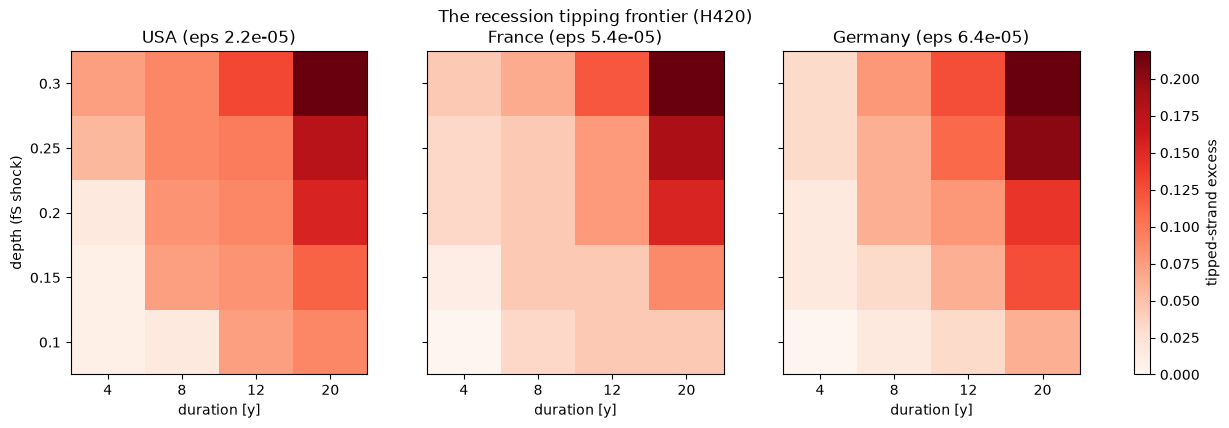

In [11]:
FIG = Path("../reports/figures"); FIG.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), sharey=True)
for ax, nm in zip(axes, LOW_WELL):
    Z = np.array([[FRONT[nm]["grid"][(d, T)]["exc"] for T in DURS] for d in DEPTHS])
    im = ax.imshow(Z, origin="lower", aspect="auto", cmap="Reds", vmin=0, vmax=max(Z.max(), 0.1))
    ax.set_xticks(range(len(DURS)), DURS); ax.set_yticks(range(len(DEPTHS)), DEPTHS)
    ax.set_xlabel("duration [y]"); ax.set_title(f"{nm} (eps {EPS_REG[nm]:.1e})")
axes[0].set_ylabel("depth (fS shock)")
fig.colorbar(im, ax=axes, label="tipped-strand excess", fraction=0.02)
fig.suptitle("The recession tipping frontier (H420)")
fig.savefig(FIG / "nb42_frontier.png", dpi=130, bbox_inches="tight"); plt.show()

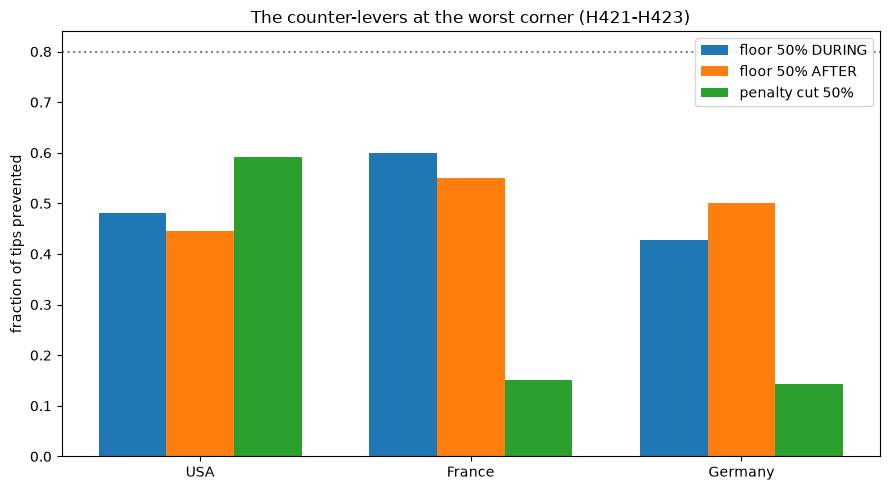

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
X = np.arange(len(LOW_WELL)); w = 0.25
ax.bar(X - w, [H421[nm]["prevented"] for nm in LOW_WELL], w, label="floor 50% DURING")
ax.bar(X, [H422[nm]["after"] for nm in LOW_WELL], w, label="floor 50% AFTER")
ax.bar(X + w, [H423[nm]["pen"] for nm in LOW_WELL], w, label="penalty cut 50%")
ax.set_xticks(X, LOW_WELL); ax.set_ylabel("fraction of tips prevented"); ax.axhline(0.8, color="grey", ls=":")
ax.set_title("The counter-levers at the worst corner (H421-H423)")
ax.legend(); fig.tight_layout(); fig.savefig(FIG / "nb42_defenses.png", dpi=130); plt.show()

## Save verdicts

In [13]:
out = dict(round="E45", hypotheses=VERDICTS,
           bundle=BCAST, grid=dict(depths=list(DEPTHS), durations=list(DURS)),
           frontier={nm: dict(ref=FRONT[nm]["ref"], ref_tfr=FRONT[nm]["ref_tfr"],
                              grid={f"{d}x{T}": v for (d, T), v in FRONT[nm]["grid"].items()})
                     for nm in LOW_WELL},
           bundle_off_control=CTRL, h421=H421, h422=H422, h423=H423, h424=H424,
           h425={f"{nm}:{arm}": v for (nm, arm), v in H425.items()},
           fold_in=FOLD_IN, eps=EPS_REG)
Path("../reports").mkdir(exist_ok=True)
p = Path("../reports/nb42_e45_verdicts.json")
if p.exists():
    prev = json.load(open(p))
    for k in ("interaction_gate", "review"):
        if k in prev:
            out[k] = prev[k]
json.dump(out, open(p, "w"), indent=2)
rprint(f"[bold green]saved[/bold green] reports/nb42_e45_verdicts.json ({len(VERDICTS)} verdicts)")
for h, v in VERDICTS.items():
    rprint(f"  {h}: {v['verdict']}")

saved reports/nb42_e45_verdicts.json (6 verdicts)

H420: SUPPORTED

H421: PARTIAL

H422: REFUTED

H423: PARTIAL

H424: PARTIAL

H425: PARTIAL

## Conclusions

**Verdicts: 1 SUPPORTED / 4 PARTIAL / 1 REFUTED** (H420 supported; H421, H423, H424, H425
partial; H422 refuted). Campaign totals move to 425 hypotheses across 45 rounds. Two verdicts
were re-graded by the round's methodology review: H422 PARTIAL -> REFUTED (its numbers refute
the hypothesis and the ladder now carries a REFUTED branch) and H425 SUPPORTED -> PARTIAL (the
observed set is degenerate - every cell tips, so the threshold criterion cannot be
discriminated from an always-tip rule, per the pre-registered degeneracy guard).

**The frontier is real, and it is entirely the pair (H420 SUPPORTED).** Across the (depth x
duration) grid the tipped-strand excess spans 0 to +0.42 in USA (0 to +0.31 France, 0 to +0.22
Germany) - a genuine frontier inside observed severities - while the SAME shocks with the
wellbeing wires off tip exactly zero strands across the FULL 5x4 grid in all three regions. The
cultural damage of a recession is not the recession; it is the deterioration feeding the
hardship broadcast.

**The defenses work but not at half price, and the timing story died honestly.** Fifty-percent
floor support prevents 43-60% of worst-corner tips (H421 PARTIAL, under the 80% bar; full-sized
defense is the recommendation). The protect-during vs repair-after contrast (H422 REFUTED) has
no timing premium at severe corners: during 0.43-0.60 vs after 0.44-0.55, with Germany's after
arm BEATING its during arm - the hysteresis-prices-the-timing hypothesis fails on its own bar,
and the practical rule collapses to SIZE, not timing. The counter-lever duel (H423 PARTIAL)
splits by regime: cutting the parenthood penalty wins in the USA (0.59 vs 0.48 - the
large-penalty country, Glass -0.127) and loses in France/Germany (0.14-0.15 - almost no penalty
to cut); floor support is the robust arm.

**Two honest nulls.** The turbulence tax (H424 PARTIAL) is below strand resolution at
mid-severity: Germany's 0.20x12y corner shows a tipped-strand excess of exactly 5/64 over the
no-shock baseline at USA's, its own, and Poland's wobble alike - the tipping there is
deterministically forced. And the Kramers pricing check (H425 PARTIAL) met its 5/6 bar
arithmetically but the observed cells are all TIP, so the criterion's sub-fold half was never
exercised, and its one distinctive prediction (France-floor, sub-fold yet tipping) is the miss:
the tipping is dynamical, not a static threshold, so the frontier map (H420) - not the fold
arithmetic - remains the honest pricing object.

**Policy reading.** Defend the parental floor during downturns at full size; where the
parenthood penalty is large, dampening the hardship broadcast (childcare access, workplace
protection) is an equally strong second arm; and do not expect the post-crisis package to repair
what the crisis tipped - at severe corners it recovers no more than the defense would have
prevented, and both under-deliver at half size.